# Module 4 — Lightweight CNN Model

## Architecture

```
Input (260-d feature vector)
   │
   ▼
Linear(260 → 128) → BatchNorm → ReLU → Dropout(0.3)
   │
   ▼
Linear(128 → 64)  → BatchNorm → ReLU → Dropout(0.3)
   │
   ▼
Linear(64 → 32)   → BatchNorm → ReLU
   │
   ▼
Linear(32 → 3)    → Sigmoid
   │
   ▼
Output: [brightness_norm, contrast_norm, gamma_norm]  ∈ [0, 1]
```

**~40 K parameters** — small enough for real-time inference.



In [2]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from config import Config

print("Imports successful.")
print(f"PyTorch version : {torch.__version__}")

Imports successful.
PyTorch version : 2.2.2+cpu


In [5]:
#Model definition 

class EnhancementCNN(nn.Module):
    """
    Fully-connected predictor for image enhancement parameters.

    Input  : (batch, 260)  — feature vector from feature_extractor
    Output : (batch, 3)    — normalised [brightness, contrast, gamma] in [0,1]
    """

    def __init__(self,
                 input_dim:  int   = 260,
                 output_dim: int   = 3,
                 dropout:    float = Config.DROPOUT_RATE):
        super().__init__()

        self.network = nn.Sequential(
            #Block 1
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),

            #Block 2
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),

            #Block 3 
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(inplace=True),

            #Output
            nn.Linear(32, output_dim),
            nn.Sigmoid()
        )

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x     : Tensor (batch_size, 260)
        return: Tensor (batch_size, 3)  — normalised params in [0, 1]
        """
        return self.network(x)

    def predict_params(self, x: torch.Tensor) -> dict:
        
        self.eval()
        with torch.no_grad():
            raw = self.forward(x)

        def rescale(v, lo, hi):
            return lo + v * (hi - lo)

        raw_np = raw.cpu().numpy()
        return {
            "brightness_factor": rescale(raw_np[:, 0], *Config.BRIGHTNESS_RANGE),
            "contrast_factor":   rescale(raw_np[:, 1], *Config.CONTRAST_RANGE),
            "gamma":             rescale(raw_np[:, 2], *Config.GAMMA_RANGE),
        }


print("EnhancementCNN class defined.")

EnhancementCNN class defined.


In [7]:
#Model summary

model = EnhancementCNN()

total   = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters     : {total:,}")
print(f"Trainable parameters : {trainable:,}")

Total parameters     : 44,291
Trainable parameters : 44,291


In [9]:
# Forward pass test

batch = torch.randn(8, 260)   # 8 samples, 260 features each
out   = model(batch)

print(f"Input  shape: {batch.shape}")
print(f"Output shape: {out.shape}")
print(f"Output range: min={out.min().item():.4f}  max={out.max().item():.4f}")
print(f"\nSample outputs (first 3 rows):")
print(out[:3].detach().numpy().round(4))

Input  shape: torch.Size([8, 260])
Output shape: torch.Size([8, 3])
Output range: min=0.0698  max=0.9010

Sample outputs (first 3 rows):
[[0.5976 0.6379 0.4448]
 [0.3225 0.785  0.7311]
 [0.5603 0.7119 0.8042]]


In [10]:
# Test predict_params (with physical unit rescaling) 

single_input = torch.randn(1, 260)
params = model.predict_params(single_input)

print("Predicted parameters (physical units):")
for k, v in params.items():
    print(f"  {k:20s} : {v[0]:.4f}")

Predicted parameters (physical units):
  brightness_factor    : 1.7373
  contrast_factor      : 0.5860
  gamma                : 1.0039


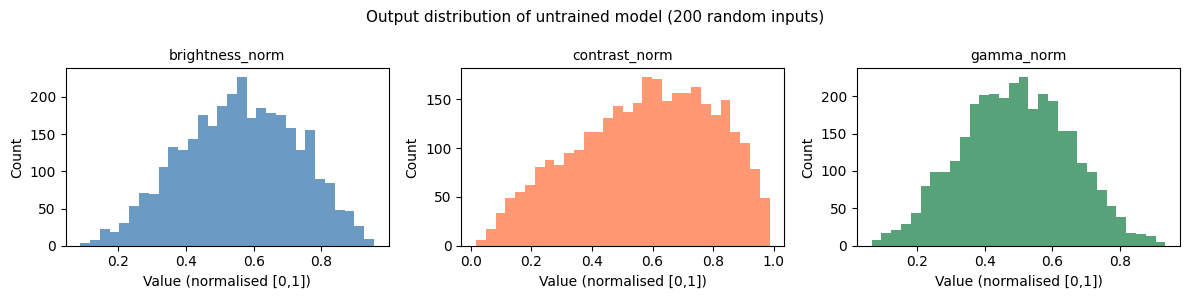

Saved cnn_output_dist.png


In [19]:
# ── Visualise network layer output distributions ──────────────────────────────

model.train()  # enable dropout for variability
all_outputs = []
for _ in range(200):
    x   = torch.randn(16, 260)
    out = model(x).detach().numpy()
    all_outputs.extend(out)

all_outputs = np.array(all_outputs)
labels      = ["brightness_norm", "contrast_norm", "gamma_norm"]
colors      = ["steelblue", "coral", "seagreen"]

fig, axes = plt.subplots(1, 3, figsize=(12, 3))
for i, (lbl, col) in enumerate(zip(labels, colors)):
    axes[i].hist(all_outputs[:, i], bins=30, color=col, alpha=0.8, edgecolor="none")
    axes[i].set_title(lbl, fontsize=10)
    axes[i].set_xlabel("Value (normalised [0,1])")
    axes[i].set_ylabel("Count")

plt.suptitle("Output distribution of untrained model (200 random inputs)", fontsize=11)
plt.tight_layout()
plt.savefig("cnn_output_dist.png", dpi=120)
plt.show()
print("Saved cnn_output_dist.png")

In [25]:
# Save module to disk
import inspect

source = """
import torch
import torch.nn as nn
import numpy as np
from config import Config

class EnhancementCNN(nn.Module):
    

    def __init__(self,
                 input_dim:  int   = 260,
                 output_dim: int   = 3,
                 dropout:    float = Config.DROPOUT_RATE):
        super().__init__()

        self.network = nn.Sequential(
            #Block 1
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),

            #Block 2
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),

            #Block 3 
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(inplace=True),

            #Output
            nn.Linear(32, output_dim),
            nn.Sigmoid()
        )

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        
        return self.network(x)

    def predict_params(self, x: torch.Tensor) -> dict:
        
        self.eval()
        with torch.no_grad():
            raw = self.forward(x)

        def rescale(v, lo, hi):
            return lo + v * (hi - lo)

        raw_np = raw.cpu().numpy()
        return {
            "brightness_factor": rescale(raw_np[:, 0], *Config.BRIGHTNESS_RANGE),
            "contrast_factor":   rescale(raw_np[:, 1], *Config.CONTRAST_RANGE),
            "gamma":             rescale(raw_np[:, 2], *Config.GAMMA_RANGE),
        }
"""

with open("cnn_model.py", "w") as f:
    f.write(source)

print("cnn_model.py written to disk.")

cnn_model.py written to disk.
